In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import tensorflow 
from tensorflow import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hafeezabro/ushape")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\ADMIN\.cache\kagglehub\datasets\hafeezabro\ushape\versions\1


In [18]:
import os
print("Files in the dataset directory:",os.listdir(path))

Files in the dataset directory: ['ushape.csv']


In [19]:
df= pd.read_csv(os.path.join(path, "ushape.csv"))

df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [20]:
# Chage column names
df=df.rename(columns={
    '3.159499363321345566e-02': 'x',
    '9.869877579082642072e-01': 'y',
    '0.000000000000000000e+00':'class',

})

Text(0.5, 1.0, 'Scatter plot of U-shape dataset')

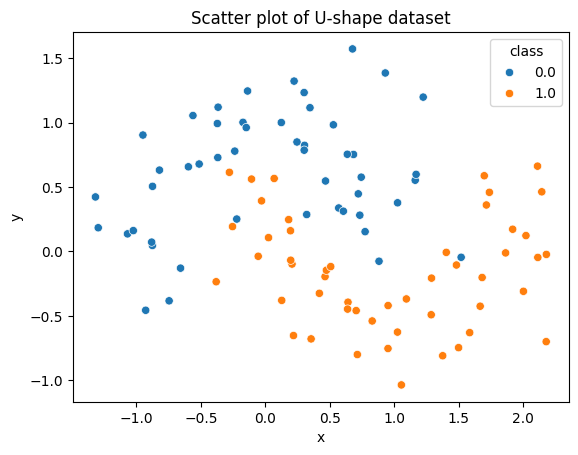

In [21]:
sns.scatterplot(data=df, x='x', y='y', hue='class')
plt.title("Scatter plot of U-shape dataset")

In [22]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [31]:
model = Sequential([
    Dense(10, activation='sigmoid', input_dim=2),
    Dense(1, activation='sigmoid')
])

d:\Programming\Deep_Learning_Concept\.deeplr\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer='adam',loss='binary_crossentropy', metrics=['accuracy']
)

history = model.fit(X,y,epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5188 - loss: 0.7898 - val_accuracy: 0.5000 - val_loss: 0.7802
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5032 - loss: 0.7946 - val_accuracy: 0.5000 - val_loss: 0.7747
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5032 - loss: 0.7931 - val_accuracy: 0.5000 - val_loss: 0.7693
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4993 - loss: 0.7855 - val_accuracy: 0.5000 - val_loss: 0.7639
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4797 - loss: 0.7982 - val_accuracy: 0.5000 - val_loss: 0.7587
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4719 - loss: 0.7946 - val_accuracy: 0.5000 - val_loss: 0.7538
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5266 - loss: 0.7556 - val_accuracy: 0.5000 - val_loss: 0.7491
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5305 - loss: 0.7475 - val_accuracy: 0.5000 - val_loss:

In [34]:
initialize_weight=model.get_weights()

In [35]:
initialize_weight

[array([[-0.07879477, -0.7612567 ,  0.6016694 , -0.72344   , -0.3941659 ,
         -0.88836575, -0.44433594,  0.6260714 ,  0.45628098,  0.7559734 ],
        [ 0.8313934 , -0.3582902 ,  0.13600129,  0.5347908 ,  0.7015264 ,
          0.12432385,  0.4336639 ,  0.42065072, -0.1722344 ,  0.4425861 ]],
       dtype=float32),
 array([ 0.07529603,  0.12026933, -0.10756112, -0.03385433,  0.10058387,
         0.16162503, -0.13318348, -0.09464944, -0.10471613, -0.09924766],
       dtype=float32),
 array([[-0.7298365 ],
        [-0.23260796],
        [ 0.45803946],
        [-0.09272729],
        [-0.79637295],
        [-0.27819538],
        [ 0.5108235 ],
        [ 0.31418663],
        [ 0.3032049 ],
        [ 0.563684  ]], dtype=float32),
 array([-0.10439429], dtype=float32)]

In [39]:
initialize_weight[0]=np.zeros(model.get_weights()[0].shape)
initialize_weight[1]=np.zeros(model.get_weights()[1].shape)
initialize_weight[2]=np.zeros(model.get_weights()[2].shape)
initialize_weight[3]=np.zeros(model.get_weights()[3].shape)


In [41]:
initialize_weight

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([0.])]

In [43]:
model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7836 - loss: 0.5979 - val_accuracy: 0.7500 - val_loss: 0.5600
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7547 - loss: 0.6089 - val_accuracy: 0.7500 - val_loss: 0.5588
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7704 - loss: 0.6056 - val_accuracy: 0.7500 - val_loss: 0.5576
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7782 - loss: 0.6038 - val_accuracy: 0.7500 - val_loss: 0.5564
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7274 - loss: 0.6108 - val_accuracy: 0.7500 - val_loss: 0.5551
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7547 - loss: 0.6022 - val_accuracy: 0.7500 - val_loss: 0.5539
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7665 - loss: 0.6000 - val_accuracy: 0.7500 - val_loss: 0.5526
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7508 - loss: 0.6061 - val_accuracy: 0.7500 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 3s 292us/step


<Axes: >

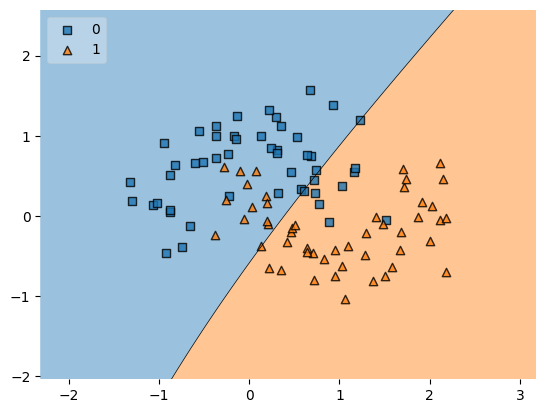

In [44]:
# %pip install mlxtend
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf=model, legend=2)